# Imports

In [91]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load in images

In [92]:
I = cv2.cvtColor(cv2.imread("I.jpg"), cv2.COLOR_BGR2GRAY)
J = cv2.cvtColor(cv2.imread("J.jpg"), cv2.COLOR_BGR2GRAY)

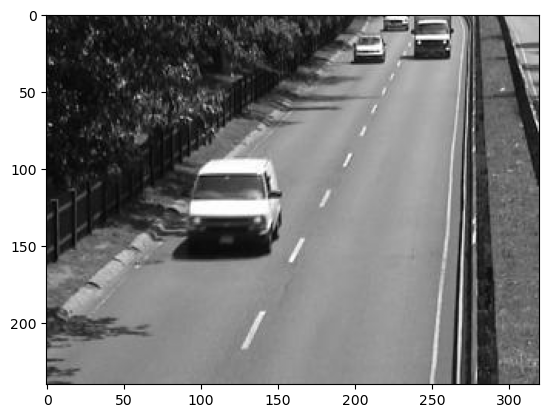

In [93]:
plt.gray()
plt.imshow(I)

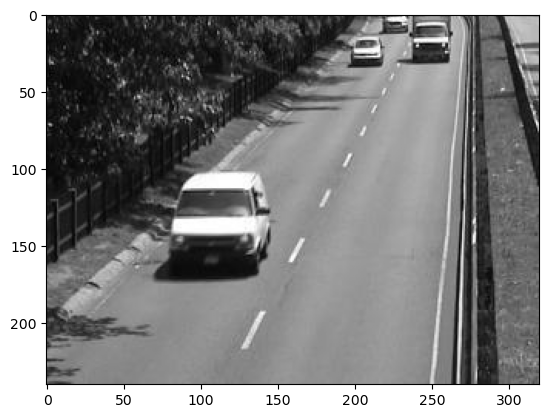

In [94]:
plt.imshow(J)

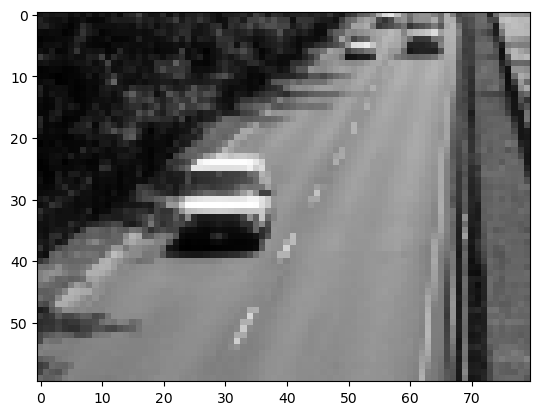

In [95]:
I_resized = cv2.resize(I, (0, 0), fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
plt.imshow(I_resized)

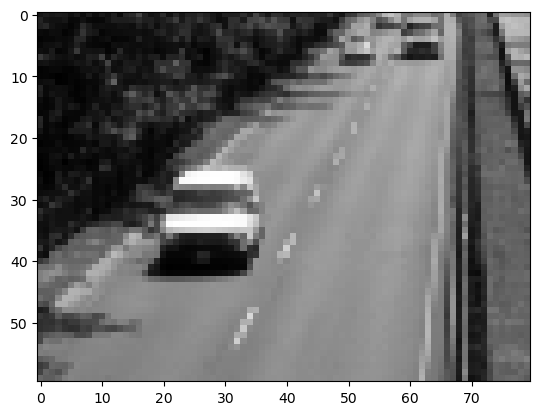

In [96]:
J_resized = cv2.resize(J, (0, 0), fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
plt.imshow(J_resized)

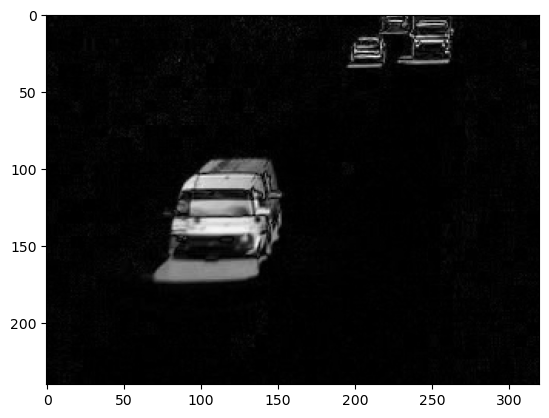

In [97]:
plt.imshow(cv2.absdiff(I, J))

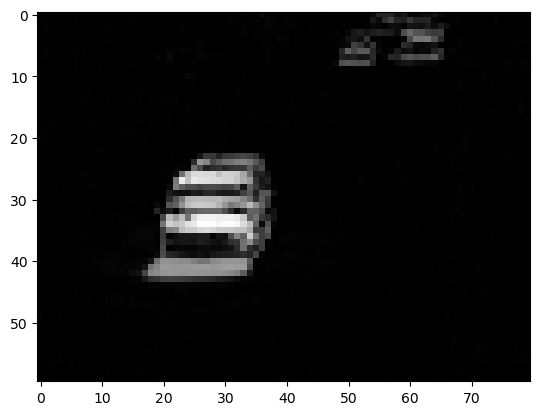

In [98]:
plt.imshow(cv2.absdiff(I_resized, J_resized))

# Block Method

## Function

In [99]:
def block_method(image_i, image_j, window_size=7, dX=3, dY=3):
    W2 = window_size // 2

    height, width = image_i.shape
    motion_x = np.zeros((height, width), dtype=np.float32)
    motion_y = np.zeros((height, width), dtype=np.float32)
    
    for row in range(W2 + dY, height - (W2 + dY)):
        for col in range(W2 + dX, width - (W2 + dX)):
            IO = np.float32(image_i[row-W2:row+W2+1,col-W2:col+W2+1])

            smallest_distance = float("inf")
            best_dx = 0
            best_dy = 0

            for dy in range(-dY, dY + 1):
                for dx in range(-dX, dX + 1):
                    JO = np.float32(image_j[row+dy-W2:row+dy+W2+1,col+dx-W2:col+dx+W2+1].copy())

                    distance = np.sqrt(np.sum((np.square(JO-IO))))
                    if distance < smallest_distance:
                        smallest_distance = distance
                        best_dx = dx
                        best_dy = dy

            motion_x[row, col] = best_dx
            motion_y[row, col] = best_dy

    return motion_x, motion_y


# Filtering

In [100]:
diff = cv2.absdiff(I, J)
diff_resized = cv2.absdiff(I_resized, J_resized)

_, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
_, thresh_resized = cv2.threshold(diff_resized, 25, 255, cv2.THRESH_BINARY)

In [101]:
kernel = np.ones((5, 5), np.uint8)

dilated_mask = cv2.dilate(thresh, kernel, iterations=1)
dilated_mask_resized = cv2.dilate(thresh_resized, kernel, iterations=1)

## Visualization

In [102]:
def visualize_motion(bm_result, image_i):
    motion_x, motion_y = bm_result

    magnitude, angle = cv2.cartToPolar(motion_x, motion_y)
    hsv = np.zeros((image_i.shape[0], image_i.shape[1], 3), dtype=np.uint8)

    hsv[..., 0] = angle * 90 / np.pi
    hsv[..., 1] = 255

    motion_scale = 255 / np.sqrt(3**2 + 3**2)
    hsv[..., 2] = np.clip(magnitude * motion_scale, 0, 255).astype(np.uint8)

    rgb_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    plt.imshow(rgb_flow)
    plt.show()

### Resized (0.25x), dX = dY = 3

In [103]:
bm_result_resized = block_method(I_resized, J_resized)

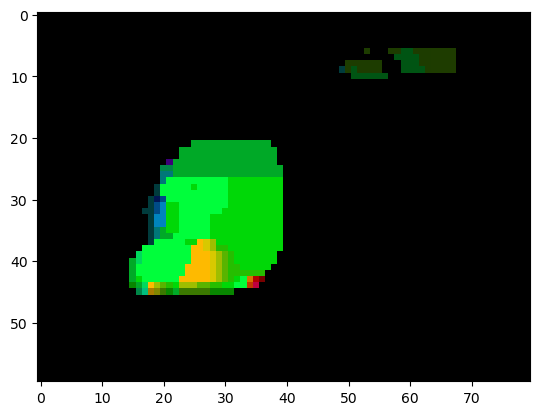

In [104]:
bm_result_resized[0][dilated_mask_resized == 0] = 0
bm_result_resized[1][dilated_mask_resized == 0] = 0
visualize_motion(bm_result_resized, I_resized)

### Actual size, dX = dY = 3

In [105]:
bm_result = block_method(I, J)

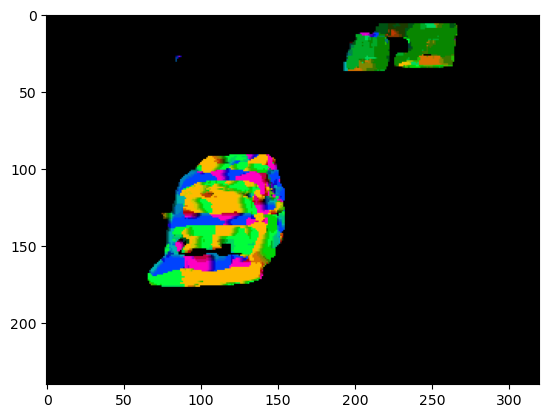

In [106]:
bm_result[0][dilated_mask == 0] = 0
bm_result[1][dilated_mask == 0] = 0
visualize_motion(bm_result, I)

### Actual size, dX = dY = 5

In [107]:
bm_result_increased_params_values = block_method(I, J, dX = 5, dY = 5)

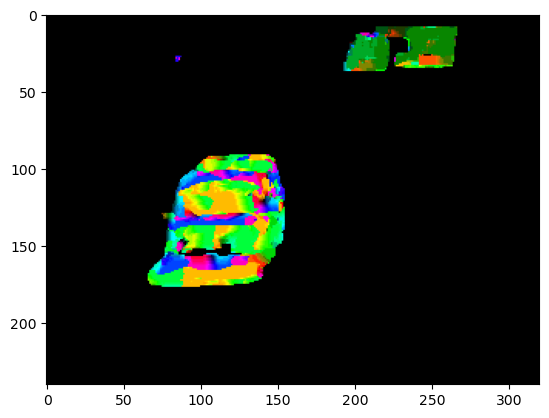

In [108]:
bm_result_increased_params_values[0][dilated_mask == 0] = 0
bm_result_increased_params_values[1][dilated_mask == 0] = 0
visualize_motion(bm_result_increased_params_values, I)